In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("LOAD DATA & INTEGRITY CHECK")

# 1. Load Data
path_data = '../data/asap_indonesia_master_2001.csv'
df = pd.read_csv(path_data)

print(f"Total Data Awal: {df.shape[0]} baris, {df.shape[1]} kolom")

# 2. Cek Missing Values
print("\n Cek Data Kosong (Missing Values):")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# 3. Hapus Data 'Off season' (Karena tidak ada tanaman yang tumbuh)
df = df[df['w_crop_na'] != 'Off season'].copy()
print(f"\n Data setelah menghapus 'Off season': {df.shape[0]} baris")

# 4. Transformasi Target EWS menjadi 5 Kelas (0, 1, 2, 3, 4)
# 0=Aman, 1=Exceptional, 2=Level 1, 3=Level 2, 4=Level 3/4
def ubah_ke_5_kelas(status):
    status = str(status)
    if status == 'No warning': return 0
    elif 'No warning with exceptional conditions' in status: return 1
    elif 'Warning level 1' in status: return 2
    elif 'Warning level 2' in status: return 3
    elif 'Warning level 3' in status or 'Warning level 4' in status: return 4
    else: return 0 

df['target_ews'] = df['w_crop_na'].apply(ubah_ke_5_kelas)

print("\n Distribusi Target EWS (0-4):")
print(df['target_ews'].value_counts().sort_index())

LOAD DATA & INTEGRITY CHECK
Total Data Awal: 29601 baris, 24 kolom

 Cek Data Kosong (Missing Values):
Soil Moisture (gapfilled historical time series)    961
dtype: int64

 Data setelah menghapus 'Off season': 28277 baris

 Distribusi Target EWS (0-4):
target_ews
0    22580
1     1002
2     2571
3     1444
4      680
Name: count, dtype: int64


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("IMPUTASI CERDAS & CLUSTERING PROVINSI")

# 1. Imputasi Nilai Kosong berbasis Provinsi
# Mengisi Soil Moisture kosong dengan nilai Median dari provinsi yang sama
kolom_soil = 'Soil Moisture (gapfilled historical time series)'
df[kolom_soil] = df.groupby('region_name')[kolom_soil].transform(lambda x: x.fillna(x.median()))

# Isi dengan median global
df[kolom_soil] = df[kolom_soil].fillna(df[kolom_soil].median())
print("Missing values di Soil Moisture berhasil ditambal.")

# 2. Hapus Kolom Bocoran Jawaban (Mencegah Data Leakage)
kolom_bocor = ['w_crop', 'w_crop_na', 'w_crop_de', 'w_crop_gr', 
               'w_range', 'w_range_na', 'w_range_de', 'w_range_gr', 'asap0_name']
df = df.drop(columns=kolom_bocor, errors='ignore')

# 3. K-MEANS CLUSTERING (K=3) BERDASARKAN PROVINSI
print("\n Memulai Proses Clustering 33 Provinsi...")

# a. Hitung rata-rata 3 variabel iklim utama untuk setiap provinsi
df_provinsi = df.groupby('region_name')[['Rainfall', 'Temperature', kolom_soil]].mean().reset_index()

# b. Samakan Skala (Scaling) agar Suhu dan Curah Hujan tidak saling mendominasi
scaler_cluster = StandardScaler()
fitur_iklim_scaled = scaler_cluster.fit_transform(df_provinsi[['Rainfall', 'Temperature', kolom_soil]])

# c. K-Means K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_provinsi['Cluster_Wilayah'] = kmeans.fit_predict(fitur_iklim_scaled)

print("Clustering Selesai! Berikut pembagian wilayahnya:")
for i in range(3):
    provinsi_di_cluster = df_provinsi[df_provinsi['Cluster_Wilayah'] == i]['region_name'].tolist()
    print(f"   => Cluster {i} ({len(provinsi_di_cluster)} Provinsi): {', '.join(provinsi_di_cluster[:5])}...")

# 4. Tempelkan Label Cluster kembali ke Data Master (76.000 baris)
df = df.merge(df_provinsi[['region_name', 'Cluster_Wilayah']], on='region_name', how='left')

# 5. Export Data Bersih untuk Pemodelan Selanjutnya...
path_export = '../data/data_master_clustered.csv'
df.to_csv(path_export, index=False)
print(f"\n Data Master Bersih berhasil disimpan ke: {path_export}")
print(f"Total Kolom Sekarang: {df.shape[1]}")

IMPUTASI CERDAS & CLUSTERING PROVINSI
Missing values di Soil Moisture berhasil ditambal.

 Memulai Proses Clustering 33 Provinsi...
Clustering Selesai! Berikut pembagian wilayahnya:
   => Cluster 0 (18 Provinsi): Banten, Dki Jakarta, Jawa Barat, Jawa Tengah, Kalimantan Barat...
   => Cluster 1 (9 Provinsi): Bali, Bangka Belitung, D.I. Yogyakarta, Gorontalo, Jawa Timur...
   => Cluster 2 (6 Provinsi): Bengkulu, Jambi, Sulawesi Tengah, Sulawesi Utara, Sumatera Barat...

 Data Master Bersih berhasil disimpan ke: ../data/data_master_clustered.csv
Total Kolom Sekarang: 17


TAHAP 3: VISUAL EDA & TEMPORAL PROCESSING
Kolom 'date' berhasil diubah ke format waktu dan fitur 'Bulan' diekstrak.


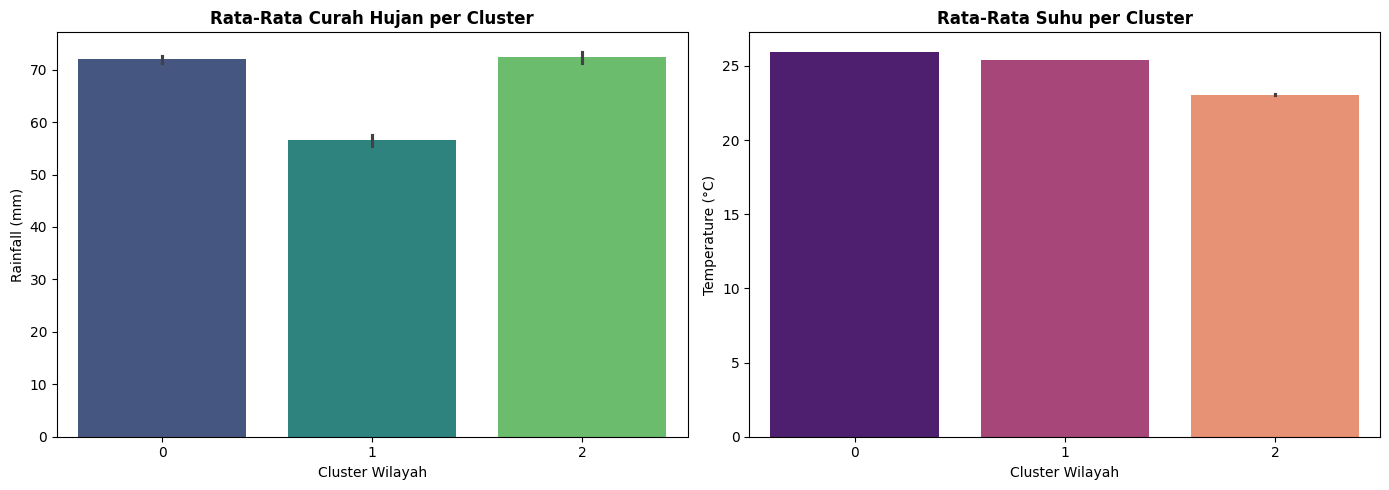


 Membuat Peta Korelasi (Heatmap)...


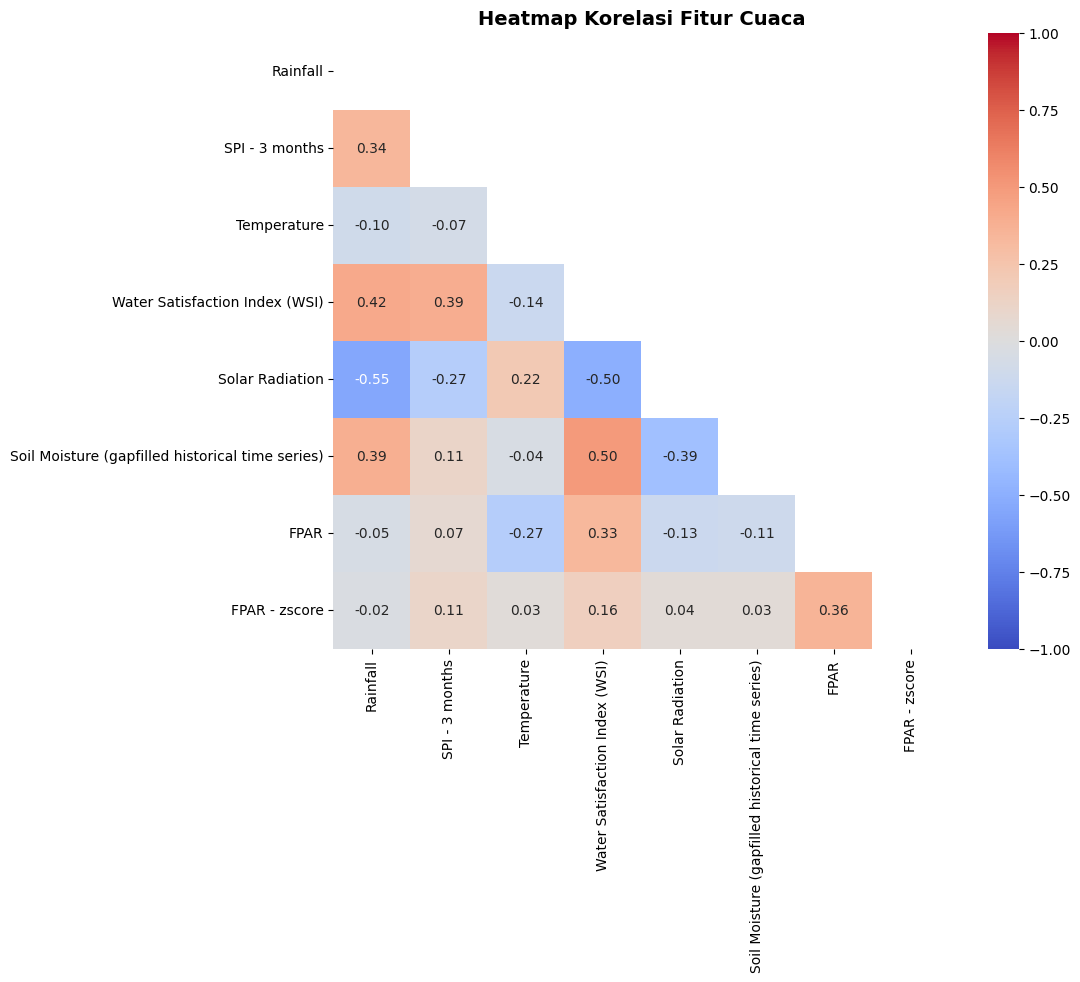

 File ../data/data_master_clustered.csv telah diperbarui dengan fitur waktu!


In [3]:
import datetime as dt

print("TAHAP 3: VISUAL EDA & TEMPORAL PROCESSING")

# 1. Mengubah kolom 'date' menjadi format Datetime (Waktu) yang benar
df['date'] = pd.to_datetime(df['date'])

# Mengekstrak Bulan sebagai fitur baru (penting untuk deteksi musim)
df['month_extracted'] = df['date'].dt.month
print("Kolom 'date' berhasil diubah ke format waktu dan fitur 'Bulan' diekstrak.")

# 2. Pembuktian Visual Hasil Clustering
# Membuat Bar Chart untuk melihat perbedaan curah hujan dan suhu antar Cluster
plt.figure(figsize=(14, 5))

# Grafik Curah Hujan antar Cluster
plt.subplot(1, 2, 1)
sns.barplot(x='Cluster_Wilayah', y='Rainfall', data=df, palette='viridis')
plt.title('Rata-Rata Curah Hujan per Cluster', fontweight='bold')
plt.xlabel('Cluster Wilayah')
plt.ylabel('Rainfall (mm)')

# Grafik Suhu antar Cluster
plt.subplot(1, 2, 2)
sns.barplot(x='Cluster_Wilayah', y='Temperature', data=df, palette='magma')
plt.title('Rata-Rata Suhu per Cluster', fontweight='bold')
plt.xlabel('Cluster Wilayah')
plt.ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

# 3. Cek Korelasi Fitur (Mencari variabel yang redundant/tumpang tindih)
print("\n Membuat Peta Korelasi (Heatmap)...")
fitur_numerik = ['Rainfall', 'SPI - 3 months', 'Temperature', 'Water Satisfaction Index (WSI)', 
                 'Solar Radiation', 'Soil Moisture (gapfilled historical time series)', 'FPAR', 'FPAR - zscore']

plt.figure(figsize=(10, 8))
korelasi = df[fitur_numerik].corr()
# Masking agar yang tampil hanya setengah segitiga bawah (lebih elegan)
mask = np.triu(np.ones_like(korelasi, dtype=bool))
sns.heatmap(korelasi, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Heatmap Korelasi Fitur Cuaca', fontweight='bold', fontsize=14)
plt.show()

# 4. Simpan Ulang Data yang sudah disempurnakan
df.to_csv(path_export, index=False)
print(f" File {path_export} telah diperbarui dengan fitur waktu!")